# Customer Review Sentiment Analysis — UrbanNest Online Store

**Author:** Jatin Kumar Puppala

## Business problem
UrbanNest (a fictional online home & electronics retailer) receives thousands of
free-text reviews per year. Star ratings tell leadership *that* satisfaction is
slipping in some places, but not *why*. Nobody has time to read 6,000 reviews.

**Questions from stakeholders**
1. How do customers feel overall, and which product categories are under-performing?
2. Can we automatically classify review sentiment accurately enough to monitor it weekly?
3. **What specifically** are customers unhappy about — product, delivery, price, support,
   packaging or assembly — and who owns the fix?
4. Are any of these problems getting worse over time?

**Approach:** data cleaning → exploratory analysis → lexicon sentiment (VADER) →
supervised ML classifier (TF-IDF + Logistic Regression) → aspect-based sentiment →
trend analysis → recommendations.

> Data note: the dataset is synthetic, produced by `src/generate_reviews.py`, and modelled
> on real e-commerce review patterns. See the README for details.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))
from aspects import explode_aspects  # noqa: E402
from domain_vader import DomainVader  # noqa: E402

IMG = ROOT / "images"
IMG.mkdir(exist_ok=True)

# Consistent, colour-blind-friendly styling
NEG, NEU, POS, ACCENT = "#d1495b", "#9aa5b1", "#2e86ab", "#3d5a80"
SENT_COLORS = {"Negative": NEG, "Neutral": NEU, "Positive": POS}
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_colwidth", 140)


def save(fig, name):
    fig.savefig(IMG / f"{name}.png", bbox_inches="tight", dpi=150)

## 1. Load and clean the data

In [2]:
raw = pd.read_csv(ROOT / "data" / "raw" / "reviews.csv", parse_dates=["review_date"])
print(f"Raw shape: {raw.shape}")
raw.head()

Raw shape: (6025, 10)


,review_id,review_date,product_id,product_name,category,region,verified_purchase,rating,helpful_votes,review_text
0,R04366,2025-07-14,P0107,Mattress Topper,Bedding & Bath,West,True,5,0,"Update after a month: Got it on sale, an absolute bargain. 5 stars from me."
1,R01130,2024-06-09,P0051,Bookshelf,Furniture,Northeast,True,3,1,"Long review but worth reading. Setup took about half an hour. Still waiting on my refund after a month, terrible customer service. Quick..."
2,R02603,2024-12-12,P0075,Wall Mirror,Home Decor,Midwest,True,2,6,Long review but worth reading. Came in a plain brown box. Mine arrived with a crack and a loose part. Do not recommend.
3,R01748,2024-09-03,P0034,Wireless Earbuds,Electronics,West,True,3,1,"Update after a month: Very well packed, everything was protected. Got it on sale, an absolute bargain. Cheap materials, the wireless ear..."
4,R03287,2025-02-24,P0023,Kettle,Kitchen Appliances,Midwest,True,4,5,"Shipping was extremely slow, it arrived way past the estimated date. Very sturdy and durable, I'm impressed."


In [3]:
quality = pd.DataFrame({
    "check": ["Duplicate rows", "Empty review text", "Missing region", "Ratings outside 1-5"],
    "rows_affected": [
        raw.duplicated().sum(),
        (raw["review_text"].fillna("").str.strip() == "").sum(),
        raw["region"].isna().sum(),
        (~raw["rating"].between(1, 5)).sum(),
    ],
})
quality

,check,rows_affected
0,Duplicate rows,24
1,Empty review text,18
2,Missing region,30
3,Ratings outside 1-5,0


In [4]:
df = (raw.drop_duplicates()
         .assign(review_text=lambda d: d["review_text"].fillna("").str.strip())
         .query("review_text != ''")
         .assign(region=lambda d: d["region"].fillna("Unknown"))
         .reset_index(drop=True))

# Target label derived from the star rating (industry-standard convention)
df["sentiment"] = pd.cut(df["rating"], bins=[0, 2, 3, 5], labels=["Negative", "Neutral", "Positive"])
df["word_count"] = df["review_text"].str.split().str.len()
df["month"] = df["review_date"].dt.to_period("M").dt.to_timestamp()

print(f"Clean shape: {df.shape}  (removed {len(raw) - len(df)} rows)")

Clean shape: (5983, 13)  (removed 42 rows)


## 2. Exploratory analysis

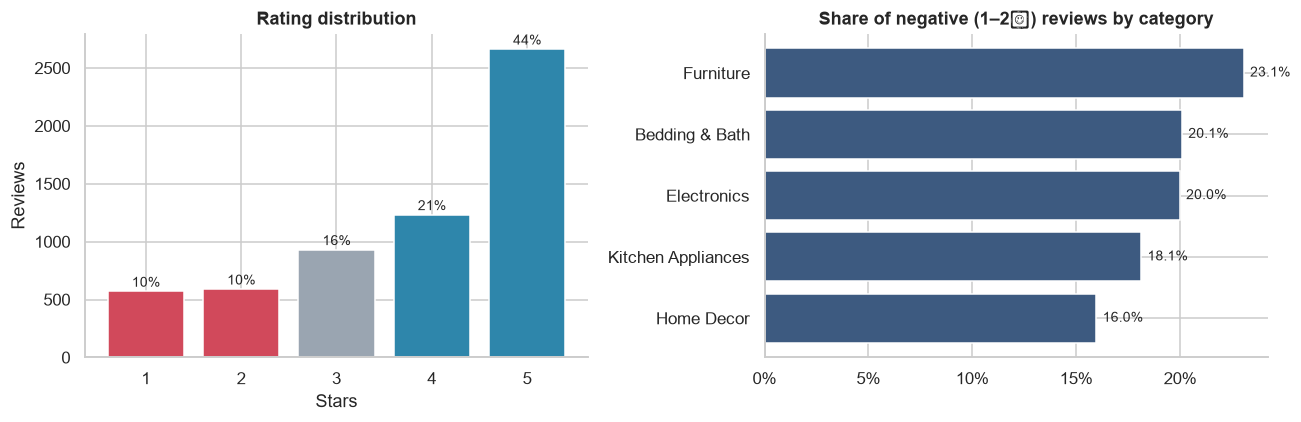

,avg_rating,pct_negative,reviews
category,,,
Home Decor,3.989,0.160,1058
Kitchen Appliances,3.849,0.181,1484
Electronics,3.746,0.200,1291
Bedding & Bath,3.841,0.201,1105
Furniture,3.602,0.231,1045


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rating_counts = df["rating"].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=[NEG, NEG, NEU, POS, POS])
axes[0].set(title="Rating distribution", xlabel="Stars", ylabel="Reviews")
for x, y in zip(rating_counts.index, rating_counts.values):
    axes[0].text(x, y + 40, f"{y / len(df):.0%}", ha="center", fontsize=9)

cat = (df.groupby("category")
         .agg(avg_rating=("rating", "mean"),
              pct_negative=("sentiment", lambda s: (s == "Negative").mean()),
              reviews=("review_id", "count"))
         .sort_values("pct_negative"))
axes[1].barh(cat.index, cat["pct_negative"], color=ACCENT)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[1].set(title="Share of negative (1–2★) reviews by category", xlabel="")
for i, v in enumerate(cat["pct_negative"]):
    axes[1].text(v + 0.003, i, f"{v:.1%}", va="center", fontsize=9)
fig.tight_layout()
save(fig, "01_ratings_overview")
plt.show()
cat.round(3)

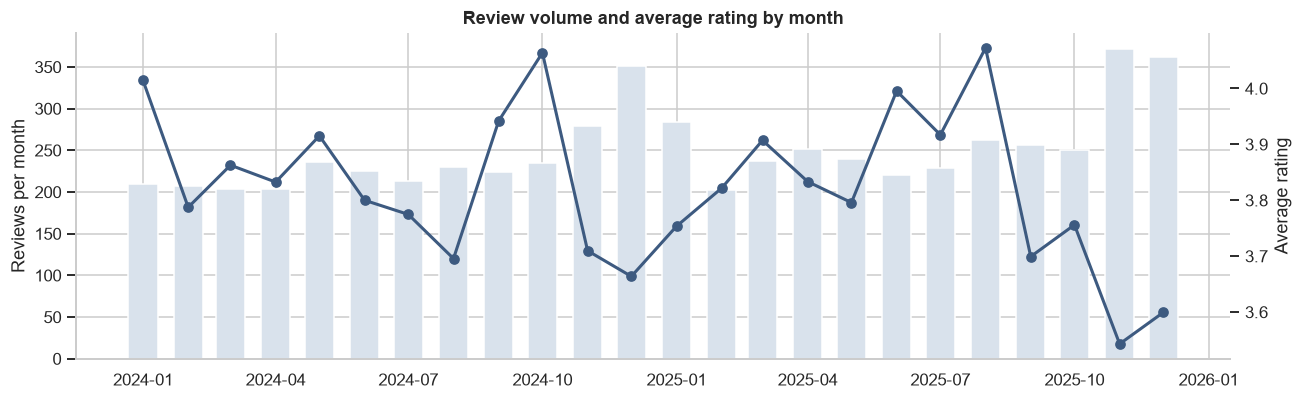

In [6]:
monthly = df.groupby("month").agg(reviews=("review_id", "count"), avg_rating=("rating", "mean"))
fig, ax1 = plt.subplots(figsize=(12, 3.8))
ax1.bar(monthly.index, monthly["reviews"], width=20, color="#d9e2ec", label="Reviews")
ax1.set_ylabel("Reviews per month")
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["avg_rating"], color=ACCENT, marker="o", lw=2, label="Avg rating")
ax2.set_ylabel("Average rating")
ax2.grid(False)
ax1.set_title("Review volume and average rating by month")
fig.tight_layout()
save(fig, "02_monthly_volume_rating")
plt.show()

## 3. Lexicon-based sentiment with VADER
VADER is a rule-based sentiment model designed for short, informal text. It needs no
training data, which makes it a quick baseline. It returns a **compound score** from
−1 (very negative) to +1 (very positive).


### Adapting VADER to retail language
Stock VADER was built for social media. Reading a sample of reviews showed it misses
many retail complaints:

In [7]:
stock_vader, vader = DomainVader(use_domain=False), DomainVader(use_domain=True)
examples = [
    "Customer service never responded to my emails.",
    "Way overpriced for what you get.",
    "The bookshelf stopped working after two weeks.",
    "Cheap materials, the lamp feels flimsy and poorly made.",
    "Contacted support three times and got three different answers.",
]
pd.DataFrame({"sentence": examples,
              "stock_VADER": [stock_vader.compound(s) for s in examples],
              "domain_VADER": [vader.compound(s) for s in examples]}).round(2)

,sentence,stock_VADER,domain_VADER
0,Customer service never responded to my emails.,0.00,-0.51
1,Way overpriced for what you get.,0.00,-0.51
2,The bookshelf stopped working after two weeks.,-0.23,-0.54
3,"Cheap materials, the lamp feels flimsy and poorly made.",0.00,-0.46
4,Contacted support three times and got three different answers.,0.40,-0.36


`src/domain_vader.py` adds about 40 retail-specific words and phrases to VADER's lexicon
("overpriced", "flimsy", "stopped working", "never responded"). It also neutralises
"support", which stock VADER treats as positive even when it is just the name of a
department. All further VADER scores use this domain version.

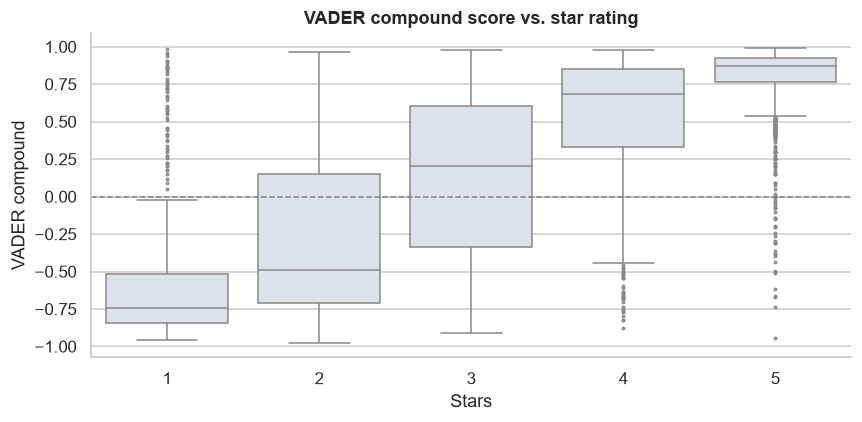

Spearman correlation (VADER vs stars): 0.72
VADER accuracy vs rating-based label: 77.9%


In [8]:
to_label = lambda s: pd.cut(s, bins=[-1.01, -0.05, 0.05, 1.01], labels=["Negative", "Neutral", "Positive"])
df["stock_vader_label"] = to_label(df["review_text"].apply(stock_vader.compound))
df["vader_compound"] = df["review_text"].apply(vader.compound)
df["vader_label"] = to_label(df["vader_compound"])

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="rating", y="vader_compound", color="#d9e2ec", ax=ax, fliersize=1.5)
ax.axhline(0, color="grey", lw=1, ls="--")
ax.set(title="VADER compound score vs. star rating", xlabel="Stars", ylabel="VADER compound")
fig.tight_layout()
save(fig, "03_vader_vs_rating")
plt.show()

print(f"Spearman correlation (VADER vs stars): "
      f"{df[['vader_compound', 'rating']].corr(method='spearman').iloc[0, 1]:.2f}")
print(f"VADER accuracy vs rating-based label: {accuracy_score(df['sentiment'], df['vader_label']):.1%}")

## 4. Supervised sentiment classifier
The VADER baseline is fast but generic. A model **trained on our own reviews** learns
domain language such as "holes don't line up" or "marked as delivered". We compare:

* **VADER**: rule-based baseline
* **Multinomial Naive Bayes**: classic text baseline
* **Logistic Regression**: TF-IDF unigrams + bigrams with class weighting

Neutral (3★) is the minority class, so **macro-F1** is the headline metric. It weights
every class equally rather than rewarding a model that only predicts "Positive".

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df["review_text"], df["sentiment"].astype(str), test_size=0.2,
    stratify=df["sentiment"], random_state=42)

# Remove common stop words but KEEP negations: "not recommend" must not collapse to "recommend"
NEGATIONS = {"not", "no", "nor", "never", "nothing", "cannot", "against"}
STOP_WORDS = sorted(ENGLISH_STOP_WORDS - NEGATIONS)

tfidf_args = dict(lowercase=True, ngram_range=(1, 2), min_df=5, sublinear_tf=True,
                  stop_words=STOP_WORDS, token_pattern=r"(?u)\b[a-zA-Z']{2,}\b")
models = {
    "Naive Bayes": make_pipeline(TfidfVectorizer(**tfidf_args), MultinomialNB(alpha=0.3)),
    "Logistic Regression": make_pipeline(
        TfidfVectorizer(**tfidf_args),
        LogisticRegression(C=1.0, max_iter=3000, class_weight="balanced")),
}

results = []
for name, col in [("VADER (stock)", "stock_vader_label"), ("VADER (domain-tuned)", "vader_label")]:
    pred = df.loc[X_test.index, col].astype(str)
    results.append({"model": name, "accuracy": accuracy_score(y_test, pred),
                    "macro_f1": f1_score(y_test, pred, average="macro")})
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({"model": name, "accuracy": accuracy_score(y_test, pred),
                    "macro_f1": f1_score(y_test, pred, average="macro")})

results = pd.DataFrame(results).set_index("model").sort_values("macro_f1")
results.style.format("{:.1%}")

,accuracy,macro_f1
model,,
VADER (stock),75.3%,55.2%
VADER (domain-tuned),77.4%,55.2%
Naive Bayes,79.9%,68.2%
Logistic Regression,78.0%,71.4%


              precision    recall  f1-score   support

    Negative      0.736     0.793     0.763       232
     Neutral      0.412     0.640     0.501       186
    Positive      0.959     0.810     0.878       779

    accuracy                          0.780      1197
   macro avg      0.702     0.748     0.714      1197
weighted avg      0.831     0.780     0.797      1197



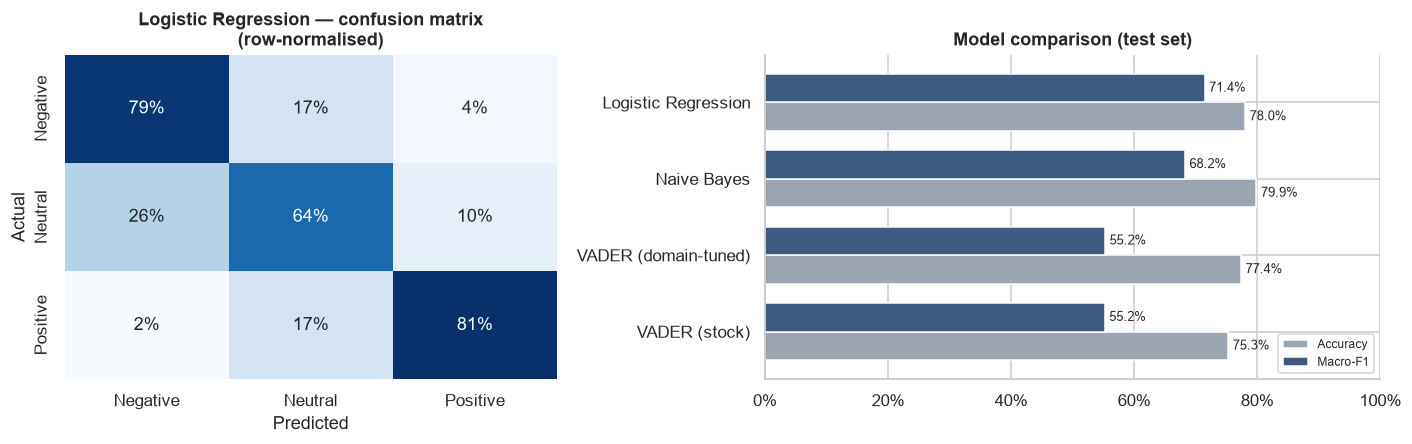

In [10]:
best = models["Logistic Regression"]
y_pred = best.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

labels = ["Negative", "Neutral", "Positive"]
cm = confusion_matrix(y_test, y_pred, labels=labels, normalize="true")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1, 1.25]})
sns.heatmap(cm, annot=True, fmt=".0%", cmap="Blues", cbar=False, xticklabels=labels,
            yticklabels=labels, ax=axes[0])
axes[0].set(title="Logistic Regression — confusion matrix\n(row-normalised)",
            xlabel="Predicted", ylabel="Actual")

results.rename(columns={"accuracy": "Accuracy", "macro_f1": "Macro-F1"}).plot.barh(
    ax=axes[1], color=[NEU, ACCENT], width=0.75)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[1].set(title="Model comparison (test set)", xlabel="", ylabel="", xlim=(0, 1))
for cont in axes[1].containers:
    axes[1].bar_label(cont, fmt=lambda v: f"{v:.1%}", padding=3, fontsize=8.5)
axes[1].legend(loc="lower right", fontsize=8)
fig.tight_layout()
save(fig, "04_model_performance")
plt.show()

### What drives the model? The most influential words and phrases
Logistic Regression is interpretable: each word or phrase has a coefficient per class.
The strongest negative-class terms read like a **list of operational failures**.

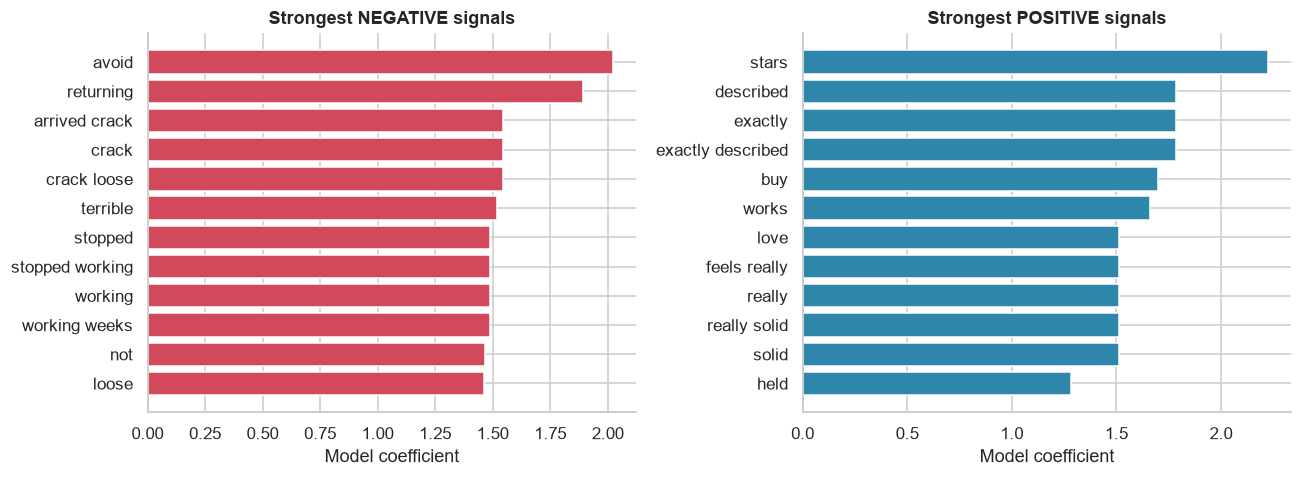

In [11]:
vec, clf = best.named_steps["tfidfvectorizer"], best.named_steps["logisticregression"]
terms = np.array(vec.get_feature_names_out())
coef = pd.DataFrame(clf.coef_.T, index=terms, columns=clf.classes_)

top_n = 12
top_neg = coef["Negative"].nlargest(top_n)[::-1]
top_pos = coef["Positive"].nlargest(top_n)[::-1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].barh(top_neg.index, top_neg.values, color=NEG)
axes[0].set_title("Strongest NEGATIVE signals")
axes[1].barh(top_pos.index, top_pos.values, color=POS)
axes[1].set_title("Strongest POSITIVE signals")
for ax in axes:
    ax.set_xlabel("Model coefficient")
fig.tight_layout()
save(fig, "05_top_terms")
plt.show()

### Error analysis
Where does the model still get it wrong? Reviewing misclassifications is how a model
gets improved in practice.

In [12]:
errors = pd.DataFrame({"text": X_test, "actual": y_test, "predicted": y_pred})
errors = errors[errors.actual != errors.predicted]
print(f"{len(errors)} misclassified out of {len(y_test)} test reviews")
errors.sample(6, random_state=7)

263 misclassified out of 1197 test reviews


,text,actual,predicted
2592,"Ordered as a gift. The air fryer is okay, does what it says. The package was delayed twice and nobody told me why. Returning it.",Negative,Neutral
480,"The app connects instantly and is simple to use. The duvet cover looks nothing like the photos, very disappointing. Very disappointed.",Neutral,Negative
1696,"Very sturdy and durable, I'm impressed. Hard to assemble, two of the panels were drilled wrong.",Positive,Neutral
4360,Long review but worth reading. The app connects instantly and is simple to use. Came in a plain brown box. Order was lost in transit and...,Positive,Neutral
495,"Quick delivery and the driver was careful. Setup took about half an hour. Defective unit, it makes a weird noise and overheats. Very dis...",Neutral,Negative
2852,"It's a standard blender, about what you'd expect.",Positive,Neutral


**Takeaway:** most errors involve the **Neutral** class. These are 3★ reviews that
mix praise and complaints (for example, great quality but slow delivery). The text
carries mixed signals and the boundary between 3★ and 4★ is subjective even for
people. Scoring each aspect separately (next section) handles this better than one
label per review.

## 5. Aspect-based sentiment: *what* are customers unhappy about?
Each review is split into sentences, and each sentence is tagged with the business area
it mentions (rule-based keyword dictionary in `src/aspects.py`) and scored with VADER.
This turns unstructured text into a table operations teams can act on.

In [13]:
asp = explode_aspects(df, id_cols=("review_id", "category", "month", "review_date"))
asp["compound"] = asp["sentence"].apply(vader.compound)
asp["is_negative"] = asp["compound"] <= -0.05
print(f"{len(asp):,} aspect mentions extracted from {asp.review_id.nunique():,} reviews "
      f"({asp.review_id.nunique() / len(df):.0%} coverage)")
asp.sample(5, random_state=3)[["sentence", "aspect", "compound"]]

14,664 aspect mentions extracted from 5,887 reviews (98% coverage)


,sentence,aspect,compound
13708,"Cheap materials, the smart plug feels flimsy and poorly made.",Product Quality,-0.0772
9372,delivery took almost three weeks and tracking never updated.,Delivery & Shipping,-0.4215
10201,Cheaper than other stores and the quality is just as good.,Product Quality,0.4404
10185,"Quality is terrible, it broke on the first use.",Product Quality,-0.7096
5885,"Update after a month: Works like a charm, no issues at all.",Product Quality,0.4588


Why domain tuning matters here: with stock VADER, complaints about **customer service**
and **price** are badly under-counted. That would have sent leadership the wrong message.

In [14]:
asp["stock_negative"] = asp["sentence"].apply(stock_vader.compound) <= -0.05
(asp.groupby("aspect")[["stock_negative", "is_negative"]].mean()
    .rename(columns={"stock_negative": "% negative (stock VADER)", "is_negative": "% negative (domain VADER)"})
    .sort_values("% negative (domain VADER)", ascending=False)
    .style.format("{:.1%}"))

,% negative (stock VADER),% negative (domain VADER)
aspect,,
Customer Service,9.7%,45.6%
Delivery & Shipping,22.1%,36.8%
Assembly & Ease of Use,34.0%,34.0%
Product Quality,23.0%,26.2%
Packaging,15.3%,15.3%
Price & Value,2.8%,11.2%


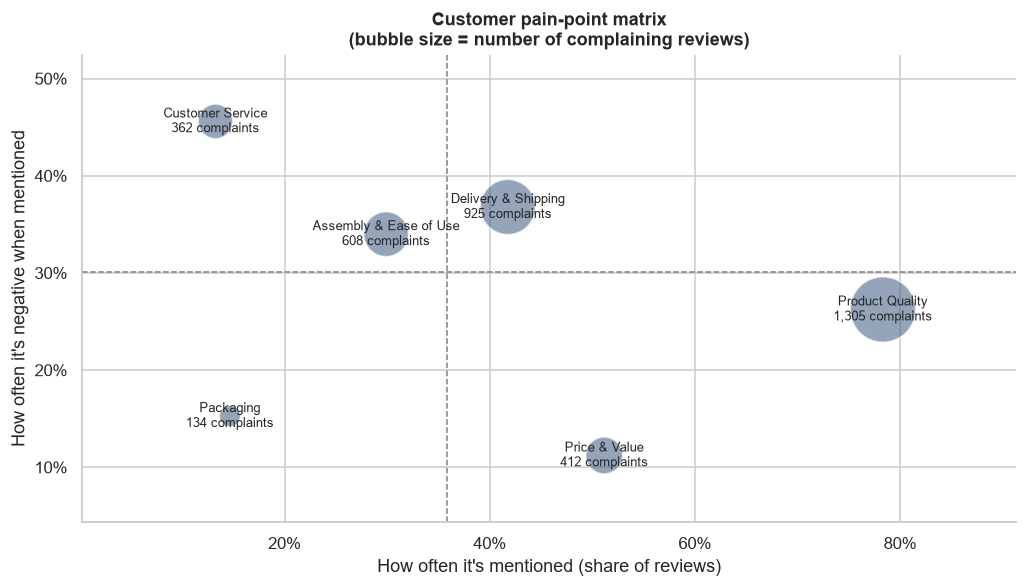

,mentions,pct_negative,avg_sentiment,share_of_reviews,negative_mentions
aspect,,,,,
Customer Service,794,0.456,-0.026,0.133,362
Delivery & Shipping,2499,0.368,-0.028,0.418,925
Assembly & Ease of Use,1789,0.340,0.067,0.299,608
Product Quality,4686,0.262,0.289,0.783,1305
Packaging,878,0.153,0.388,0.147,134
Price & Value,3061,0.112,0.323,0.512,412


In [15]:
summary = (asp.groupby("aspect")
              .agg(mentions=("review_id", "nunique"),
                   pct_negative=("is_negative", "mean"),
                   avg_sentiment=("compound", "mean"))
              .assign(share_of_reviews=lambda d: d["mentions"] / len(df))
              .sort_values("pct_negative", ascending=False))
# "Negative mentions" = how many reviews complain about this aspect: the priority metric
summary["negative_mentions"] = (asp[asp.is_negative].groupby("aspect")["review_id"].nunique()
                                .reindex(summary.index))

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.scatter(summary["share_of_reviews"], summary["pct_negative"],
           s=summary["negative_mentions"] * 1.4, color=ACCENT, alpha=0.55, edgecolor="white")
for name, r in summary.iterrows():
    ax.annotate(f"{name}\n{int(r.negative_mentions):,} complaints",
                (r.share_of_reviews, r.pct_negative), ha="center", va="center", fontsize=8.5)
ax.axhline(summary["pct_negative"].median(), color="grey", ls="--", lw=1)
ax.axvline(summary["share_of_reviews"].median(), color="grey", ls="--", lw=1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set(title="Customer pain-point matrix\n(bubble size = number of complaining reviews)",
       xlabel="How often it's mentioned (share of reviews)",
       ylabel="How often it's negative when mentioned")
ax.margins(0.2)
fig.tight_layout()
save(fig, "06_pain_point_matrix")
plt.show()
summary.round(3)

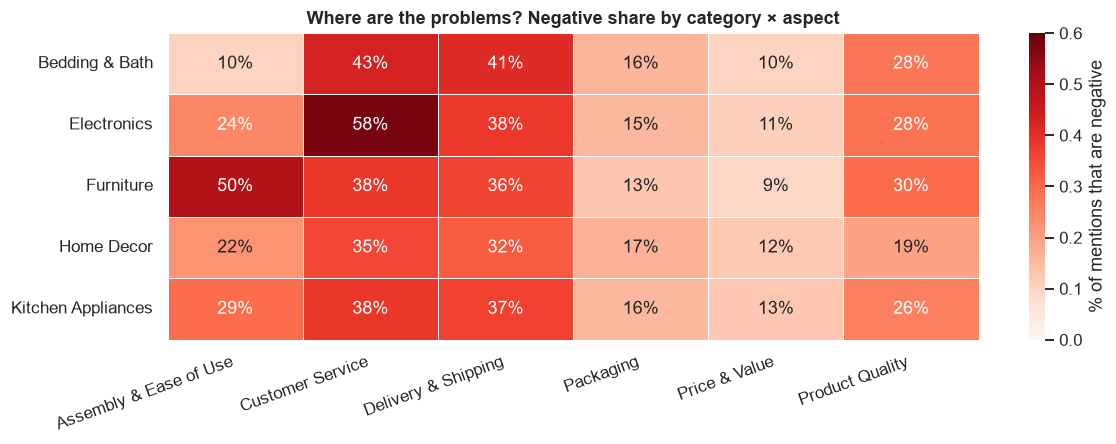

In [16]:
heat = (asp.pivot_table(index="category", columns="aspect", values="is_negative", aggfunc="mean"))
counts = asp.pivot_table(index="category", columns="aspect", values="is_negative", aggfunc="size")
heat = heat.where(counts >= 30)   # hide cells with too few mentions to be reliable

fig, ax = plt.subplots(figsize=(11, 4.2))
sns.heatmap(heat, annot=True, fmt=".0%", cmap="Reds", vmin=0, vmax=0.6,
            linewidths=0.5, cbar_kws={"label": "% of mentions that are negative"}, ax=ax)
ax.set(title="Where are the problems? Negative share by category × aspect",
       xlabel="", ylabel="")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()
save(fig, "07_category_aspect_heatmap")
plt.show()

## 6. Trends: are problems getting better or worse?

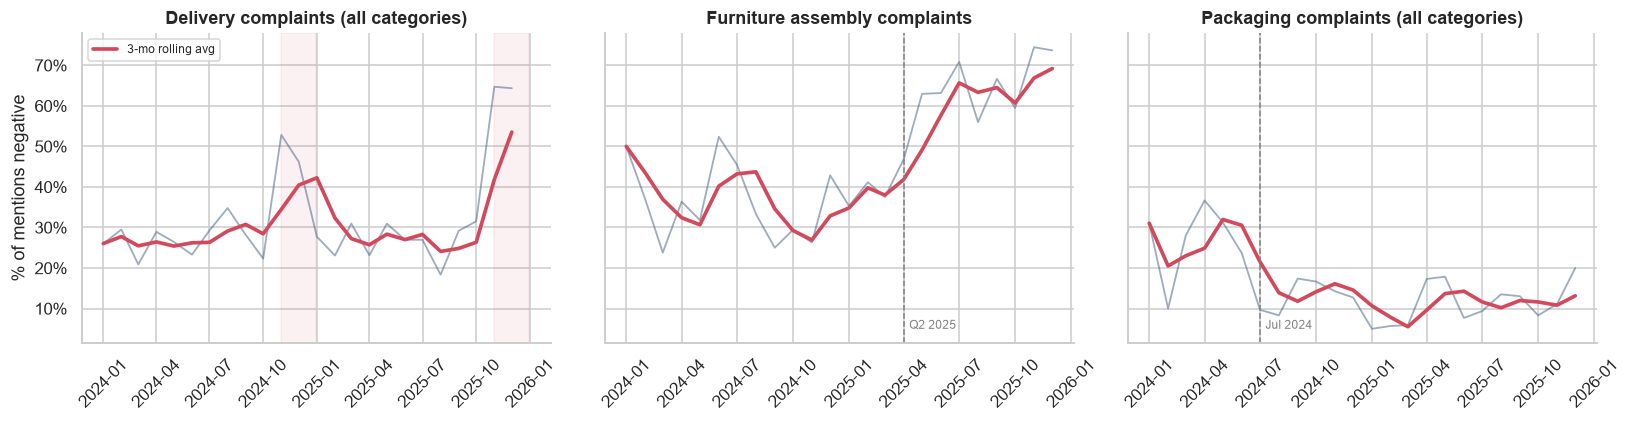

In [17]:
def monthly_negative_share(frame, aspect, category=None):
    f = frame[frame.aspect == aspect]
    if category:
        f = f[f.category == category]
    return f.groupby("month")["is_negative"].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
series = [
    ("Delivery & Shipping", None, "Delivery complaints (all categories)"),
    ("Assembly & Ease of Use", "Furniture", "Furniture assembly complaints"),
    ("Packaging", None, "Packaging complaints (all categories)"),
]
for ax, (aspect, cat_, title) in zip(axes, series):
    s = monthly_negative_share(asp, aspect, cat_)
    ax.plot(s.index, s.values, color=ACCENT, lw=1.2, alpha=0.5)
    ax.plot(s.index, s.rolling(3, min_periods=1).mean(), color=NEG, lw=2.4, label="3-mo rolling avg")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("% of mentions negative")
axes[0].legend(loc="upper left", fontsize=8)
# Highlight the holiday peaks
for yr in (2024, 2025):
    axes[0].axvspan(pd.Timestamp(f"{yr}-11-01"), pd.Timestamp(f"{yr}-12-31"), color=NEG, alpha=0.08)
axes[1].axvline(pd.Timestamp("2025-04-01"), color="grey", ls="--", lw=1)
axes[1].text(pd.Timestamp("2025-04-10"), 0.05, "Q2 2025", fontsize=8, color="grey")
axes[2].axvline(pd.Timestamp("2024-07-01"), color="grey", ls="--", lw=1)
axes[2].text(pd.Timestamp("2024-07-10"), 0.05, "Jul 2024", fontsize=8, color="grey")
fig.tight_layout()
save(fig, "08_aspect_trends")
plt.show()

In [18]:
# Quantify the changes behind the charts
d = asp[asp.aspect == "Delivery & Shipping"].assign(
    holiday=lambda f: f.month.dt.month.isin([11, 12]), year=lambda f: f.month.dt.year)
holiday_tbl = d.pivot_table(index="year", columns="holiday", values="is_negative", aggfunc="mean")
holiday_tbl.columns = ["Jan–Oct", "Nov–Dec (holiday)"]
print("Delivery: % negative mentions")
display(holiday_tbl.style.format("{:.1%}"))

f = asp[(asp.aspect == "Assembly & Ease of Use") & (asp.category == "Furniture")]
furn = f.groupby(f.review_date.dt.to_period("Q"))["is_negative"].mean()
print("Furniture assembly: % negative mentions by quarter")
display(furn.to_frame("pct_negative").T.style.format("{:.0%}"))

p = asp[asp.aspect == "Packaging"]
before = p[p.review_date < "2024-07-01"].is_negative.mean()
after = p[p.review_date >= "2024-07-01"].is_negative.mean()
print(f"Packaging: {before:.1%} negative before Jul 2024 -> {after:.1%} after")

Delivery: % negative mentions


,Jan–Oct,Nov–Dec (holiday)
year,,
2024,27.1%,49.2%
2025,26.9%,64.5%


Furniture assembly: % negative mentions by quarter


review_date,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4
pct_negative,37%,40%,36%,35%,37%,56%,65%,70%


Packaging: 26.6% negative before Jul 2024 -> 12.2% after


## 7. Export scored data
The scored reviews can feed a BI dashboard (Power BI or Tableau) for weekly monitoring.

In [19]:
out = ROOT / "data" / "processed"
out.mkdir(parents=True, exist_ok=True)
df.assign(predicted_sentiment=best.predict(df["review_text"])).to_csv(out / "reviews_scored.csv", index=False)
asp.to_csv(out / "aspect_mentions.csv", index=False)
print("Saved processed files to", out.relative_to(ROOT))

Saved processed files to data\processed


## 8. Key insights and recommendations

| # | Finding | Evidence | Recommendation | Owner |
|---|---------|----------|----------------|-------|
| 1 | **Holiday delivery failures are getting worse.** | Negative delivery mentions jump from ~27% (Jan–Oct) to **49% in Nov–Dec 2024** and **65% in Nov–Dec 2025**. | Add peak-season carrier capacity from October, set more conservative delivery estimates in Nov–Dec, and send proactive delay notifications. | Logistics |
| 2 | **Furniture assembly problems roughly doubled from Q2 2025.** | Negative assembly mentions rose from **37% to 65%**. Complaints cite misaligned holes, missing screws and unclear instructions. The timing points to a supplier or design change. | Audit Q2 2025 furniture suppliers, add a hardware checklist at packing, and publish video assembly guides. | Merchandising / Supplier QA |
| 3 | **Electronics has a customer-support problem.** | **58%** of Electronics service mentions are negative, against 35–43% in other categories. | Set up a dedicated Electronics support queue with a 24-hour response SLA, and track first-contact resolution. | Customer Service |
| 4 | **Product quality is the largest driver of negative reviews.** | **70%** of 1–2★ reviews include a negative quality sentence. Delivery follows at 31%. | Flag products whose share of negative quality mentions exceeds the category baseline for vendor review each month. | Category Management |
| 5 | **The July 2024 packaging redesign worked.** | Negative packaging mentions fell from **27% to 12%** after the change. | Treat it as a success case and use the same before/after measurement for future operational changes. | Operations |
| 6 | **Price is not the problem.** | Only **11%** of price mentions are negative, the lowest of any aspect. | Avoid discounting in response to falling ratings. Fix fulfilment and quality first. | Pricing / Marketing |

### Model takeaways
* **TF-IDF + Logistic Regression** is the chosen model, with the best macro-F1 (~0.71)
  at ~78% accuracy. Naive Bayes has slightly *higher* accuracy but leans towards the
  majority Positive class and misses more Negative and Neutral reviews. Those are the
  reviews the business most needs to catch, which is why accuracy alone is the wrong
  metric here.
* Neutral (3★) reviews are hardest to classify because they mix praise and complaints.
* **Off-the-shelf tools can mislead.** Stock VADER flagged fewer than 1 in 10 customer
  service mentions as negative. After domain tuning, the figure is about **46%**. Without
  that step, the service problem in finding 3 would have stayed hidden.

### Next steps
* Deploy the classifier as a weekly batch job feeding a BI dashboard, with alerts when an
  aspect's negative share moves more than 10 percentage points above its 3-month average.
* Replace the keyword-based aspect tagger with a zero-shot or fine-tuned transformer model
  (for example, a BERT-family model) once labelled sentence-level data is available.